# Ensemble + Bias Investigation
 
1. Feature pipeline with all Person C additions
2. LambdaRank and pointwise model training (with new features)
3. Ensemble: weighted combination, alpha sweep
4. Bias investigation: detection, mitigation (re-weighting), evaluation

In [2]:
import sys
from pathlib import Path
 
cwd = Path(".").resolve()
REPO_ROOT = cwd if (cwd / ".git").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))
 
import json
 
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
 
from src.utils import (
    load_train,
    load_train_cached_sample,
    train_val_split,
    compute_ndcg_fast,
)
from src.features import build_features
from src.svd_features import build_svd_features
from src.position_features import build_position_features
 
# Set to None for full data (final run). Use 0.15 for dev.
SAMPLE_FRAC = 0.15

### Load Data + Build All Features

In [16]:
"""
1. Data Loading and Feature Engineering
"""
 
if SAMPLE_FRAC is not None:
    df = load_train_cached_sample(sample_frac=SAMPLE_FRAC)
    print(f"Loaded {SAMPLE_FRAC*100:.0f}% sample: {len(df):,} rows, "
          f"{df['srch_id'].nunique():,} searches")
else:
    df = load_train()
    print(f"Loaded full data: {len(df):,} rows, {df['srch_id'].nunique():,} searches")
 
n_raw = df.shape[1]
df = build_features(df)
print(f"Base features: {n_raw} raw + {df.shape[1] - n_raw} engineered = {df.shape[1]} total")

Loaded 15% sample: 742,438 rows, 29,969 searches
Base features: 54 raw + 64 engineered = 118 total


In [17]:
"""
2. Train/Val Split + Leakage-Safe Features
"""
 
train_df, val_df = train_val_split(df)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}")
 
# SVD features (leakage-safe: built from train fold only)
n_before = df.shape[1]
df = build_svd_features(train_df, df)
print(f"SVD features added: {df.shape[1] - n_before}")
 
# Position-debiased features (leakage-safe: built from train fold only)
n_before = df.shape[1]
df = build_position_features(train_df, df)
print(f"Position-debiased features added: {df.shape[1] - n_before}")
 
# Re-split to get the augmented train/val (same random_state=42)
train_df, val_df = train_val_split(df)
print(f"Final feature count: {df.shape[1]}")

Train: 593,717  Val: 148,721
SVD features added: 43
Position-debiased features added: 6
Final feature count: 167


In [18]:
"""
3. Prepare Feature Matrix
"""
 
DROP_COLS = [
    "srch_id", "date_time", "position", "click_bool", "booking_bool",
    "gross_bookings_usd", "random_bool",
]
COMP_RAW = [
    f"comp{i}_{s}" for i in range(1, 9)
    for s in ("rate", "inv", "rate_percent_diff")
]
drop = set(DROP_COLS + COMP_RAW)
feature_cols = [c for c in train_df.columns if c not in drop]
 
print(f"Features for modeling: {len(feature_cols)}")
 
X_train = train_df[feature_cols]
X_val = val_df[feature_cols]

Features for modeling: 136


### Train Models

In [19]:
"""
4. Train LambdaRank
"""
 
def make_relevance(frame):
    """booking=5, click-only=1, nothing=0"""
    return (frame["booking_bool"] * 5 +
            (frame["click_bool"] - frame["booking_bool"]).clip(lower=0)).values
 
y_train_rel = make_relevance(train_df)
y_val_rel = make_relevance(val_df)
y_train_binary = train_df["booking_bool"].values
y_val_binary = val_df["booking_bool"].values
 
group_train = train_df.groupby("srch_id").size().values
group_val = val_df.groupby("srch_id").size().values
 
# LambdaRank — best params from Prita's tuning
lr_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5],
    "num_leaves": 63,
    "learning_rate": 0.01,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "feature_pre_filter": False,
    "num_threads": -1,
    "verbose": -1,
    "seed": 42,
}
 
lr_train_set = lgb.Dataset(X_train, label=y_train_rel, group=group_train)
lr_val_set = lgb.Dataset(X_val, label=y_val_rel, group=group_val, reference=lr_train_set)
 
lr_model = lgb.train(
    lr_params, lr_train_set,
    valid_sets=[lr_val_set],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)],
)
 
val_df_eval = val_df[["srch_id", "prop_id", "booking_bool", "click_bool"]].copy()
val_df_eval["lr_score"] = lr_model.predict(X_val)
lr_ndcg = compute_ndcg_fast(val_df_eval, "lr_score")
print(f"LambdaRank NDCG@5: {lr_ndcg:.4f}")

Training until validation scores don't improve for 50 rounds
[200]	valid_0's ndcg@5: 0.34275
[400]	valid_0's ndcg@5: 0.352066
[600]	valid_0's ndcg@5: 0.358026
Early stopping, best iteration is:
[599]	valid_0's ndcg@5: 0.358265
LambdaRank NDCG@5: 0.3588


In [20]:
"""
5. Train Pointwise LightGBM
"""
 
pw_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 255,
    "learning_rate": 0.01,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "feature_pre_filter": False,
    "num_threads": -1,
    "verbose": -1,
    "seed": 42,
}
 
pw_train_set = lgb.Dataset(X_train, label=y_train_binary)
pw_val_set = lgb.Dataset(X_val, label=y_val_binary, reference=pw_train_set)
 
pw_model = lgb.train(
    pw_params, pw_train_set,
    valid_sets=[pw_val_set],
    num_boost_round=4000,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(500)],
)
 
val_df_eval["pw_score"] = pw_model.predict(X_val)
pw_ndcg = compute_ndcg_fast(val_df_eval, "pw_score")
print(f"Pointwise NDCG@5:  {pw_ndcg:.4f}")

Training until validation scores don't improve for 50 rounds
[500]	valid_0's binary_logloss: 0.112592
Early stopping, best iteration is:
[850]	valid_0's binary_logloss: 0.112291
Pointwise NDCG@5:  0.3707


### Ensemble

  alpha=0.0  NDCG@5=0.3707
  alpha=0.1  NDCG@5=0.3723
  alpha=0.2  NDCG@5=0.3727
  alpha=0.3  NDCG@5=0.3737
  alpha=0.4  NDCG@5=0.3738
  alpha=0.5  NDCG@5=0.3742
  alpha=0.6  NDCG@5=0.3751
  alpha=0.7  NDCG@5=0.3735
  alpha=0.8  NDCG@5=0.3711
  alpha=0.9  NDCG@5=0.3640
  alpha=1.0  NDCG@5=0.3588

Best ensemble: alpha=0.6, NDCG@5=0.3751
LambdaRank alone:  0.3588
Pointwise alone:   0.3707
Ensemble gain:     +0.0044


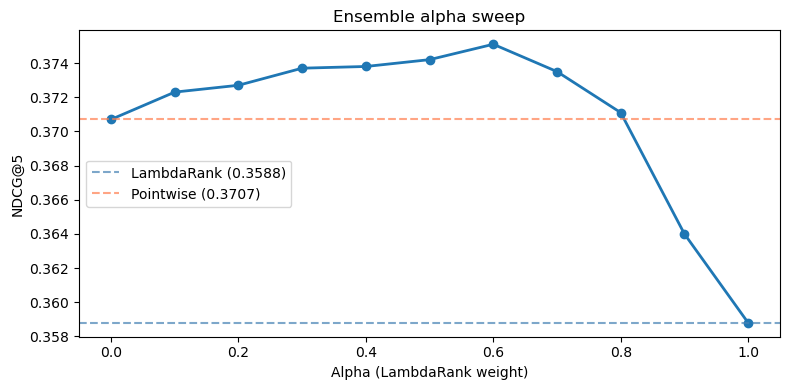

In [21]:
"""
6. Ensemble: Weighted Average
 
Sweep alpha in [0, 1] where:
  ensemble_score = alpha * norm(lr_score) + (1 - alpha) * norm(pw_score)
 
Normalise per-search to put both scores on comparable scales.
"""
 
def normalize_per_search(df, col):
    """Min-max normalise scores within each search to [0, 1]."""
    g = df.groupby("srch_id")[col]
    mn = g.transform("min")
    mx = g.transform("max")
    rng = (mx - mn).replace(0, 1)  # avoid division by zero
    return ((df[col] - mn) / rng).astype("float32")
 
val_df_eval["lr_norm"] = normalize_per_search(val_df_eval, "lr_score")
val_df_eval["pw_norm"] = normalize_per_search(val_df_eval, "pw_score")
 
alphas = np.arange(0.0, 1.05, 0.1)
ensemble_results = []
 
for alpha in alphas:
    val_df_eval["ensemble_score"] = (
        alpha * val_df_eval["lr_norm"] + (1 - alpha) * val_df_eval["pw_norm"]
    )
    ndcg = compute_ndcg_fast(val_df_eval, "ensemble_score")
    ensemble_results.append({"alpha": round(alpha, 2), "ndcg5": round(ndcg, 4)})
    print(f"  alpha={alpha:.1f}  NDCG@5={ndcg:.4f}")
 
ensemble_df = pd.DataFrame(ensemble_results)
best_row = ensemble_df.loc[ensemble_df["ndcg5"].idxmax()]
best_alpha = best_row["alpha"]
best_ensemble_ndcg = best_row["ndcg5"]
 
print(f"\nBest ensemble: alpha={best_alpha:.1f}, NDCG@5={best_ensemble_ndcg:.4f}")
print(f"LambdaRank alone:  {lr_ndcg:.4f}")
print(f"Pointwise alone:   {pw_ndcg:.4f}")
print(f"Ensemble gain:     +{best_ensemble_ndcg - max(lr_ndcg, pw_ndcg):.4f}")
 
# Set the best ensemble as the final score
val_df_eval["ensemble_score"] = (
    best_alpha * val_df_eval["lr_norm"]
    + (1 - best_alpha) * val_df_eval["pw_norm"]
)
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ensemble_df["alpha"], ensemble_df["ndcg5"], marker="o", linewidth=2)
ax.axhline(lr_ndcg, linestyle="--", color="steelblue", alpha=0.7, label=f"LambdaRank ({lr_ndcg:.4f})")
ax.axhline(pw_ndcg, linestyle="--", color="coral", alpha=0.7, label=f"Pointwise ({pw_ndcg:.4f})")
ax.set_xlabel("Alpha (LambdaRank weight)")
ax.set_ylabel("NDCG@5")
ax.set_title("Ensemble alpha sweep")
ax.legend()
plt.tight_layout()
plt.show()

### Bias Investigation

In [22]:
"""
7. Bias Investigation
 
7.1 Define Protected Groups
"""
 
# Primary: family vs non-family
val_df_eval["is_family"] = (val_df["srch_children_count"].values > 0).astype(int)
 
# Secondary: domestic vs international
val_df_eval["is_domestic"] = (
    val_df["visitor_location_country_id"].values == val_df["prop_country_id"].values
).astype(int)
 
family_counts = val_df_eval.groupby("srch_id")["is_family"].first().value_counts()
domestic_counts = val_df_eval.groupby("srch_id")["is_domestic"].first().value_counts()
 
print("Group sizes (by unique searches):")
print(f"  Family:        {family_counts.get(1, 0):,}")
print(f"  Non-family:    {family_counts.get(0, 0):,}")
print(f"  Domestic:      {domestic_counts.get(1, 0):,}")
print(f"  International: {domestic_counts.get(0, 0):,}")

Group sizes (by unique searches):
  Family:        1,451
  Non-family:    4,543
  Domestic:      3,743
  International: 2,251


In [23]:
"""
7.2 Detect Bias: Per-Group NDCG@5
"""
 
score_col = "ensemble_score"  # evaluate bias on the ensemble (final model)
 
 
def per_group_ndcg(eval_df, group_col, score_col):
    """Compute NDCG@5 separately for each group."""
    results = {}
    for group_val, label in [(0, f"not_{group_col}"), (1, group_col)]:
        mask = eval_df[group_col] == group_val
        subset = eval_df[mask]
        if len(subset) == 0:
            continue
        ndcg = compute_ndcg_fast(subset, score_col)
        results[label] = {"ndcg5": round(ndcg, 4), "n_searches": subset["srch_id"].nunique()}
    return results
 
 
family_ndcg = per_group_ndcg(val_df_eval, "is_family", score_col)
domestic_ndcg = per_group_ndcg(val_df_eval, "is_domestic", score_col)
 
print("\nPer-group NDCG@5 (ensemble):")
print("  Family analysis:")
for k, v in family_ndcg.items():
    print(f"    {k}: NDCG@5={v['ndcg5']:.4f} ({v['n_searches']:,} searches)")
 
print("  Domestic/international analysis:")
for k, v in domestic_ndcg.items():
    print(f"    {k}: NDCG@5={v['ndcg5']:.4f} ({v['n_searches']:,} searches)")


Per-group NDCG@5 (ensemble):
  Family analysis:
    not_is_family: NDCG@5=0.3702 (4,543 searches)
    is_family: NDCG@5=0.3902 (1,451 searches)
  Domestic/international analysis:
    not_is_domestic: NDCG@5=0.3596 (2,255 searches)
    is_domestic: NDCG@5=0.3833 (3,751 searches)


In [24]:
"""
7.3 Adapted Fairness Metrics for Ranking
 
The ethics lecture defines demographic parity and error rate balance for binary classification. We adapt these to ranking:
 
Demographic parity (ranking): P(hotel in top-5 | group=A) should equal P(hotel in top-5 | group=B). In ranking terms: the fraction of searches
where the booked hotel appears in the model's top-5 should be similar across groups.
 
Error rate balance (ranking): The recall@5 (fraction of booked hotels that the model places in the top-5) should be equal across groups.
This is the ranking analog of equal FNR: "how often does the model fail to surface the booked hotel?"
"""
 
 
def ranking_fairness_metrics(eval_df, group_col, score_col):
    """
    Compute adapted fairness metrics for ranking.
 
    Returns per-group:
    - top5_rate: P(booked hotel in top-5) — demographic parity analog
    - recall_at_5: fraction of booked hotels placed in top-5 — error rate balance analog
    """
    df = eval_df.copy()
    df["_neg_score"] = -df[score_col]
    df["_rank"] = df.groupby("srch_id")["_neg_score"].rank(method="first").astype(int)
 
    # For each search, check if ANY booked hotel is in the top-5
    booked = df[df["booking_bool"] == 1].copy()
    booked["booked_in_top5"] = (booked["_rank"] <= 5).astype(int)
 
    # Merge group info at search level
    search_group = df.groupby("srch_id")[group_col].first()
    booked = booked.merge(search_group.rename("_group"), left_on="srch_id", right_index=True)
 
    results = {}
    for gval in sorted(booked["_group"].unique()):
        g = booked[booked["_group"] == gval]
        n_booked = len(g)
        n_in_top5 = g["booked_in_top5"].sum()
        results[int(gval)] = {
            "recall_at_5": round(n_in_top5 / max(n_booked, 1), 4),
            "n_bookings": n_booked,
        }
    return results
 
 
family_fairness = ranking_fairness_metrics(val_df_eval, "is_family", score_col)
domestic_fairness = ranking_fairness_metrics(val_df_eval, "is_domestic", score_col)
 
print("\nFairness metrics — family vs non-family:")
for gval, metrics in family_fairness.items():
    label = "Family" if gval == 1 else "Non-family"
    print(f"  {label}: recall@5={metrics['recall_at_5']:.4f} ({metrics['n_bookings']:,} bookings)")
 
print("\nFairness metrics — domestic vs international:")
for gval, metrics in domestic_fairness.items():
    label = "Domestic" if gval == 1 else "International"
    print(f"  {label}: recall@5={metrics['recall_at_5']:.4f} ({metrics['n_bookings']:,} bookings)")


Fairness metrics — family vs non-family:
  Non-family: recall@5=0.5760 (3,125 bookings)
  Family: recall@5=0.5917 (1,041 bookings)

Fairness metrics — domestic vs international:
  International: recall@5=0.5636 (1,455 bookings)
  Domestic: recall@5=0.5887 (2,711 bookings)


In [25]:
"""
7.4 Bias Mitigation: Re-Weighting (Petrovic et al. 2022)
 
Pre-processing technique from the ethics lecture. Assign higher training weights to underperforming group's positive examples to make the model
pay more attention to them during learning.
"""
 
# Determine which group is underperforming from the detection step (This will be known after running 7.2 and 7.3)
 
# Re-weighting: upweight the underrepresented group's bookings using family/non-family as the primary analysis
 
train_df_bias = train_df.copy()
train_df_bias["is_family"] = (train_df_bias["srch_children_count"] > 0).astype(int)
 
# Compute per-group booking prevalence
family_book_rate = train_df_bias.loc[
    train_df_bias["is_family"] == 1, "booking_bool"
].mean()
nonfamily_book_rate = train_df_bias.loc[
    train_df_bias["is_family"] == 0, "booking_bool"
].mean()
 
print(f"\nTraining booking rates:")
print(f"  Family:     {family_book_rate:.4f}")
print(f"  Non-family: {nonfamily_book_rate:.4f}")
 
# Compute sample weights: upweight the group with lower booking prevalence
# Following Petrovic et al.: weight = 1/prevalence for underrepresented positives
weights = np.ones(len(train_df_bias), dtype="float32")
 
# Identify the underperforming group from bias detection
# Upweight their positive examples (bookings)
family_mask = train_df_bias["is_family"] == 1
booked_mask = train_df_bias["booking_bool"] == 1
 
# Upweight family bookings (typically the smaller, underperforming group)
family_booked = family_mask & booked_mask
nonfamily_booked = (~family_mask) & booked_mask
 
# Weight ratio: balance the effective number of positive examples
n_family_booked = family_booked.sum()
n_nonfamily_booked = nonfamily_booked.sum()
 
if n_family_booked > 0 and n_nonfamily_booked > 0:
    # Scale so both groups contribute equally to the loss
    ratio = n_nonfamily_booked / n_family_booked
    weights[family_booked] = ratio
    print(f"\nRe-weighting: family bookings upweighted by {ratio:.2f}x")
    print(f"  Family bookings:     {n_family_booked:,} (weight={ratio:.2f})")
    print(f"  Non-family bookings: {n_nonfamily_booked:,} (weight=1.0)")


Training booking rates:
  Family:     0.0297
  Non-family: 0.0272

Re-weighting: family bookings upweighted by 3.10x
  Family bookings:     4,028 (weight=3.10)
  Non-family bookings: 12,475 (weight=1.0)


In [26]:
"""
7.5 Retrain with Weights and Evaluate
"""
 
# Retrain pointwise model with re-weighted loss (pointwise supports sample_weight)
pw_train_weighted = lgb.Dataset(
    X_train, label=y_train_binary, weight=weights
)
pw_val_set2 = lgb.Dataset(X_val, label=y_val_binary, reference=pw_train_weighted)
 
pw_model_fair = lgb.train(
    pw_params, pw_train_weighted,
    valid_sets=[pw_val_set2],
    num_boost_round=4000,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(500)],
)
 
val_df_eval["pw_fair_score"] = pw_model_fair.predict(X_val)
pw_fair_ndcg = compute_ndcg_fast(val_df_eval, "pw_fair_score")
 
print(f"\nPointwise (original) NDCG@5:    {pw_ndcg:.4f}")
print(f"Pointwise (re-weighted) NDCG@5: {pw_fair_ndcg:.4f}")
print(f"Overall NDCG change:            {pw_fair_ndcg - pw_ndcg:+.4f}")
 
# Per-group comparison before vs after
print("\nPer-group NDCG@5 comparison:")
for score, label in [("pw_score", "Original"), ("pw_fair_score", "Re-weighted")]:
    groups = per_group_ndcg(val_df_eval, "is_family", score)
    print(f"  {label}:")
    for k, v in groups.items():
        print(f"    {k}: {v['ndcg5']:.4f}")
 
# Fairness metrics before vs after
print("\nFairness metrics comparison (recall@5):")
for score, label in [("pw_score", "Original"), ("pw_fair_score", "Re-weighted")]:
    metrics = ranking_fairness_metrics(val_df_eval, "is_family", score)
    print(f"  {label}:")
    for gval, m in metrics.items():
        group_label = "Family" if gval == 1 else "Non-family"
        print(f"    {group_label}: {m['recall_at_5']:.4f}")

Training until validation scores don't improve for 50 rounds
[500]	valid_0's binary_logloss: 0.115835
[1000]	valid_0's binary_logloss: 0.113947
[1500]	valid_0's binary_logloss: 0.113173
Early stopping, best iteration is:
[1808]	valid_0's binary_logloss: 0.112976

Pointwise (original) NDCG@5:    0.3707
Pointwise (re-weighted) NDCG@5: 0.3719
Overall NDCG change:            +0.0012

Per-group NDCG@5 comparison:
  Original:
    not_is_family: 0.3654
    is_family: 0.3875
  Re-weighted:
    not_is_family: 0.3675
    is_family: 0.3859

Fairness metrics comparison (recall@5):
  Original:
    Non-family: 0.5773
    Family: 0.5965
  Re-weighted:
    Non-family: 0.5853
    Family: 0.6013


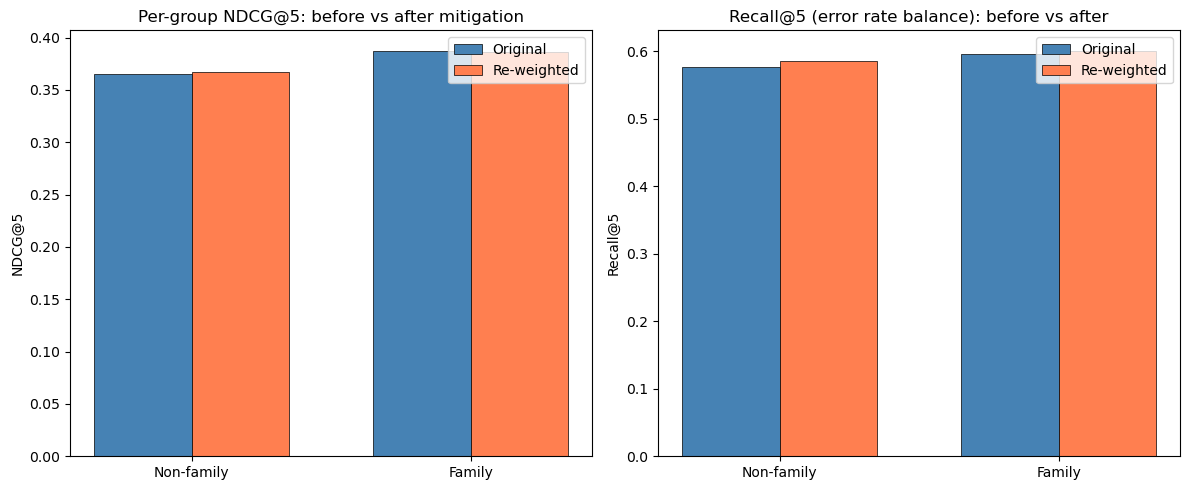

In [27]:
"""
7.6 Visualization: Before vs After
"""
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# NDCG comparison
labels_ndcg = ["Non-family", "Family"]
original_ndcg = per_group_ndcg(val_df_eval, "is_family", "pw_score")
fair_ndcg = per_group_ndcg(val_df_eval, "is_family", "pw_fair_score")
 
orig_vals = [original_ndcg.get("not_is_family", {}).get("ndcg5", 0),
             original_ndcg.get("is_family", {}).get("ndcg5", 0)]
fair_vals = [fair_ndcg.get("not_is_family", {}).get("ndcg5", 0),
             fair_ndcg.get("is_family", {}).get("ndcg5", 0)]
 
x = np.arange(len(labels_ndcg))
w = 0.35
axes[0].bar(x - w/2, orig_vals, w, label="Original", color="steelblue", edgecolor="black", linewidth=0.5)
axes[0].bar(x + w/2, fair_vals, w, label="Re-weighted", color="coral", edgecolor="black", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_ndcg)
axes[0].set_ylabel("NDCG@5")
axes[0].set_title("Per-group NDCG@5: before vs after mitigation")
axes[0].legend()
 
# Recall@5 comparison
orig_fairness = ranking_fairness_metrics(val_df_eval, "is_family", "pw_score")
fair_fairness = ranking_fairness_metrics(val_df_eval, "is_family", "pw_fair_score")
 
orig_recall = [orig_fairness.get(0, {}).get("recall_at_5", 0),
               orig_fairness.get(1, {}).get("recall_at_5", 0)]
fair_recall = [fair_fairness.get(0, {}).get("recall_at_5", 0),
               fair_fairness.get(1, {}).get("recall_at_5", 0)]
 
axes[1].bar(x - w/2, orig_recall, w, label="Original", color="steelblue", edgecolor="black", linewidth=0.5)
axes[1].bar(x + w/2, fair_recall, w, label="Re-weighted", color="coral", edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_ndcg)
axes[1].set_ylabel("Recall@5")
axes[1].set_title("Recall@5 (error rate balance): before vs after")
axes[1].legend()
 
plt.tight_layout()
plt.show()

### Save Results

In [28]:
"""
8. Save Results
"""
 
out_dir = REPO_ROOT / "outputs"
out_dir.mkdir(exist_ok=True)
 
results_out = {
    "ensemble": {
        "best_alpha": float(best_alpha),
        "ndcg5": float(best_ensemble_ndcg),
        "lambdarank_ndcg5": float(lr_ndcg),
        "pointwise_ndcg5": float(pw_ndcg),
    },
    "bias_investigation": {
        "group": "family_vs_nonfamily",
        "detection": {
            "family_ndcg5": family_ndcg.get("is_family", {}).get("ndcg5"),
            "nonfamily_ndcg5": family_ndcg.get("not_is_family", {}).get("ndcg5"),
        },
        "mitigation": "re-weighting (Petrovic et al. 2022)",
        "original_overall_ndcg5": float(pw_ndcg),
        "mitigated_overall_ndcg5": float(pw_fair_ndcg),
    },
    "sample_frac": SAMPLE_FRAC,
}
 
with open(out_dir / "ensemble_bias_results.json", "w") as f:
    json.dump(results_out, f, indent=2)
 
print(f"Results saved to outputs/ensemble_bias_results.json")
print("\nDone.")

Results saved to outputs/ensemble_bias_results.json

Done.
